# Predicción de la Excentricidad Orbital de Exoplanetas
## NASA Exoplanet Archive Intelligence Dataset

**Autor:** Jheison Martinez Bolivar  
**Maestría:** Inteligencia Artificial  
**Fecha:** Agosto 2026  
**Dataset:** [NASA Exoplanet Archive Intelligence – Kaggle](https://www.kaggle.com/datasets/kanchana1990/nasa-exoplanet-archive-intelligence)

---

### Planteamiento del Proyecto
El objetivo de este cuaderno es realizar un Análisis Exploratorio de Datos (EDA) sobre el catálogo de exoplanetas de la NASA para comprender la estructura del dataset, evaluar la presencia de valores faltantes y justificar la elección de nuestra variable objetivo (*target*).

A partir de esta exploración, prepararemos los datos y compararemos dos enfoques de Machine Learning:
- **Regresión Lineal** (modelo baseline)
- **Random Forest** (modelo no lineal de ensamble)

In [1]:
# ── 1. Librerías ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")
print("✓ Librerías cargadas")

✓ Librerías cargadas


## 1. Exploración de Datos (EDA)

In [2]:
# ── 2. Carga de datos ───────────────────────────────────────────────────────
path = kagglehub.dataset_download("kanchana1990/nasa-exoplanet-archive-intelligence")
df_raw = pd.read_csv(path + "/nasa_exoplanet_intelligence.csv")

print(f"Dataset: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print()
df_raw.head(3)

Dataset: 6,150 filas x 31 columnas



,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)


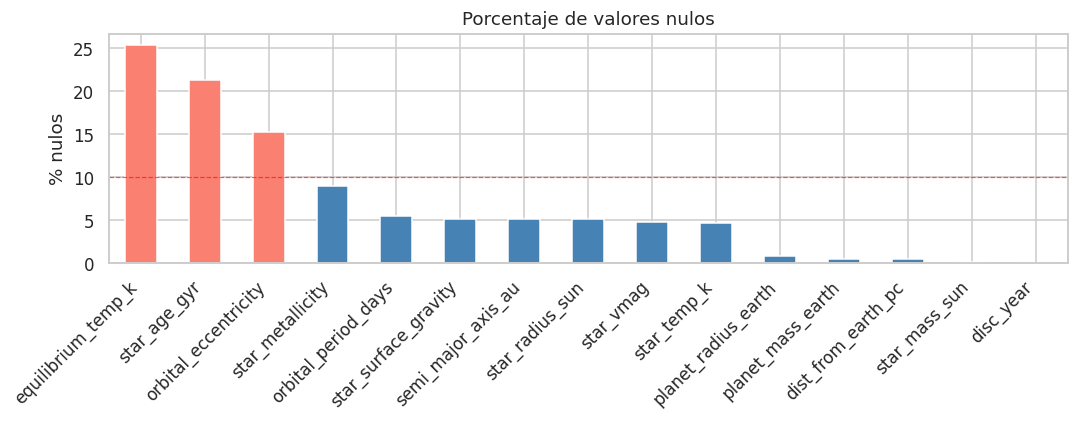

Variables con nulos:
equilibrium_temp_k      25.41
star_age_gyr            21.32
orbital_eccentricity    15.25
star_metallicity         8.94
orbital_period_days      5.43
star_surface_gravity     5.17
semi_major_axis_au       5.14
star_radius_sun          5.11
star_vmag                4.80
star_temp_k              4.72
planet_radius_earth      0.81
planet_mass_earth        0.50
dist_from_earth_pc       0.44
star_mass_sun            0.13
disc_year                0.02


In [3]:
# ── 3. Análisis de valores nulos ────────────────────────────────────────────
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
null_pct_nonzero = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["salmon" if v > 10 else "steelblue" for v in null_pct_nonzero.values]
null_pct_nonzero.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Porcentaje de valores nulos", fontsize=12)
ax.set_ylabel("% nulos")
ax.axhline(10, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Variables con nulos:")
print(null_pct_nonzero.round(2).to_string())

### Elección Justificada de la Variable Objetivo (*Target*)

Tras analizar el porcentaje de valores nulos en el dataset:

1. **Descarte de variables con alto porcentaje de nulos:**
   - `equilibrium_temp_k` (25.4%) y `star_age_gyr` (21.3%) presentan un número excesivo de datos faltantes. Descartamos su uso como características (*features*) para evitar eliminar demasiadas observaciones.

2. **Selección del Target (`orbital_eccentricity`):**
   - La **excentricidad orbital** presenta un **15.25% de valores nulos**.
   - **Justificación científica y práctica:** La excentricidad es una medida compleja que requiere observaciones prolongadas de la velocidad radial de las estrellas. Predecirla mediante propiedades mejor conocidas (como la masa, el radio planetario o la distancia) permite imputar y completar este dato en más de 900 exoplanetas del catálogo de la NASA.

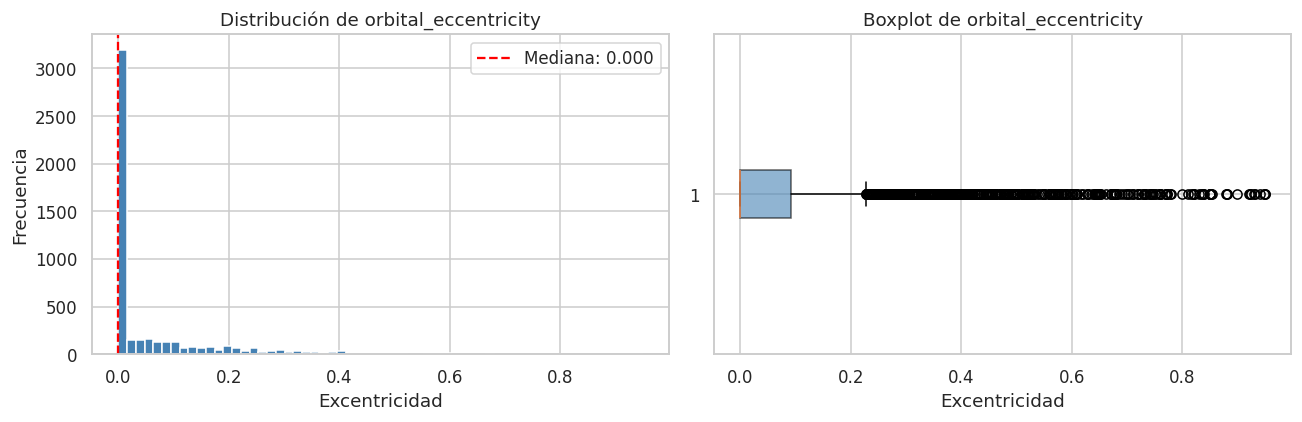

count    5212.0000
mean        0.0792
std         0.1529
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0910
max         0.9500
Name: orbital_eccentricity, dtype: float64


In [4]:
# ── 4. Distribución del target: orbital_eccentricity ────────────────────────
TARGET = "orbital_eccentricity"
FEATURES = [
    "planet_radius_earth", "planet_mass_earth",
    "semi_major_axis_au", "orbital_period_days",
    "star_temp_k", "star_radius_sun", "star_mass_sun",
    "star_surface_gravity", "star_metallicity",
    "dist_from_earth_pc", "star_vmag", "ra", "dec"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw[TARGET].dropna(), bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de orbital_eccentricity")
axes[0].set_xlabel("Excentricidad")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(df_raw[TARGET].median(), color="red", linestyle="--", label=f"Mediana: {df_raw[TARGET].median():.3f}")
axes[0].legend()

axes[1].boxplot(df_raw[TARGET].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Boxplot de orbital_eccentricity")
axes[1].set_xlabel("Excentricidad")

plt.tight_layout()
plt.show()

print(df_raw[TARGET].describe().round(4))

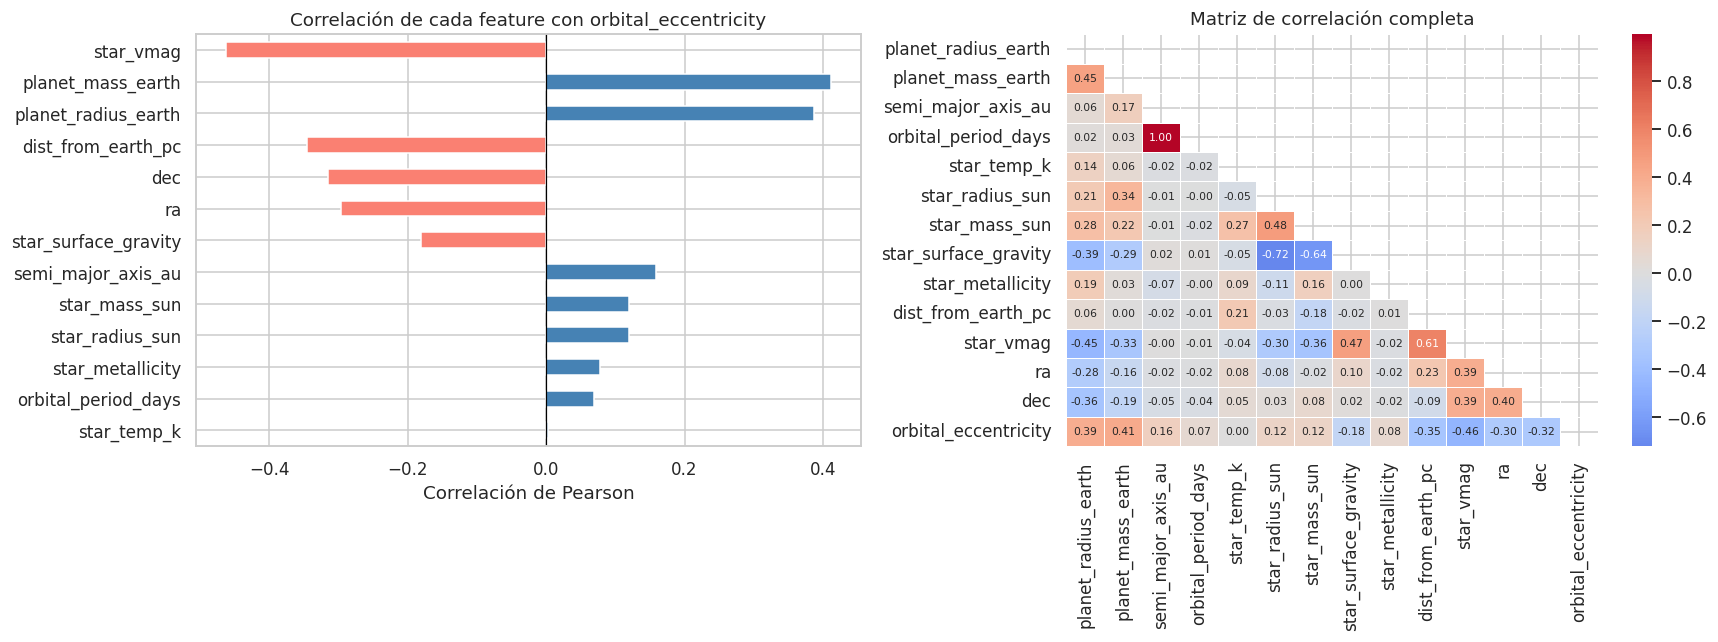

In [5]:
# ── 5. Correlación entre features y target ──────────────────────────────────
corr_cols = FEATURES + [TARGET]
corr = df_raw[corr_cols].corr()
corr_target = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ["salmon" if v < 0 else "steelblue" for v in corr_target.values]
corr_target.plot(kind="barh", ax=axes[0], color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Correlación de cada feature con orbital_eccentricity")
axes[0].set_xlabel("Correlación de Pearson")

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[1], linewidths=0.4, annot_kws={"size": 7})
axes[1].set_title("Matriz de correlación completa")

plt.tight_layout()
plt.show()

### Análisis de Correlación y Decisión de Modelado

De la matriz de correlación se derivan las siguientes observaciones clave:

1. **Principales correlaciones con el target (`orbital_eccentricity`):**
   - `star_vmag` ($\approx -0.46$): Estrellas con menor magnitud visual (más brillantes) presentan órbitas detectadas con menor excentricidad.
   - `planet_mass_earth` ($\approx +0.41$) y `planet_radius_earth` ($\approx +0.39$): Planetas más masivos y grandes tienden a mostrar órbitas más elípticas.

2. **Justificación para comparar modelos:**
   - Ninguna variable supera un coeficiente $|r| > 0.5$, lo que demuestra la **ausencia de relaciones lineales fuertes** individuales.
   - Esto anticipa que un modelo baseline de **Regresión Lineal** tendrá un alcance limitado, justificando la necesidad de un modelo no lineal como **Random Forest**, capaz de aprender interacciones complejas entre múltiples características astronómicas.

## 2. Preprocesamiento de Datos

Para entrenar nuestros modelos de regresión, aplicamos los siguientes pasos:
1. **Limpieza:** Filtramos filas descartando valores nulos en el *target* o en las *features* seleccionadas.
2. **Partición:** Dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%).
3. **Escalado Estandarizado:** Aplicamos `StandardScaler` ($z = \frac{x - \mu}{\sigma}$) a las variables predictoras. Esto es fundamental para la Regresión Lineal, pues variables como el período orbital (días) y la masa tienen escalas numéricas muy dispares.

In [6]:
# ── 6. Preprocesamiento y escalado ──────────────────────────────────────────
df = df_raw[FEATURES + [TARGET]].dropna()
print(f"Filas después de dropna: {len(df):,} (de {len(df_raw):,} originales)")
print(f"Filas eliminadas: {len(df_raw) - len(df):,} ({(1 - len(df)/len(df_raw))*100:.1f}%)")

y = df[TARGET].values
X = df[FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("✓ Preprocesamiento y escalado completados con éxito")

Filas después de dropna: 4,925 (de 6,150 originales)
Filas eliminadas: 1,225 (19.9%)
Train: 3,940 | Test: 985
✓ Preprocesamiento y escalado completados con éxito


## 3. Regresión Lineal

La regresión lineal modela la relación como:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

**Supuesto clave:** Asume una relación lineal entre las características y la excentricidad. Dado que las correlaciones individuales son moderadas (máx ~0.46), evaluaremos el alcance y las limitaciones de este enfoque baseline.

In [7]:
# ── 7. Regresión Lineal - Entrenamiento y métricas ──────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
cv_lr   = cross_val_score(lr, scaler.transform(X), y, cv=5, scoring="r2")

print("=== Regresión Lineal ===")
print(f"R2        (test):  {r2_lr:.4f}")
print(f"RMSE      (test):  {rmse_lr:.4f}")
print(f"MAE       (test):  {mae_lr:.4f}")
print(f"R2 CV-5fold:       {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}")

=== Regresión Lineal ===
R2        (test):  0.2721
RMSE      (test):  0.1158
MAE       (test):  0.0681
R2 CV-5fold:       0.3166 +/- 0.0415


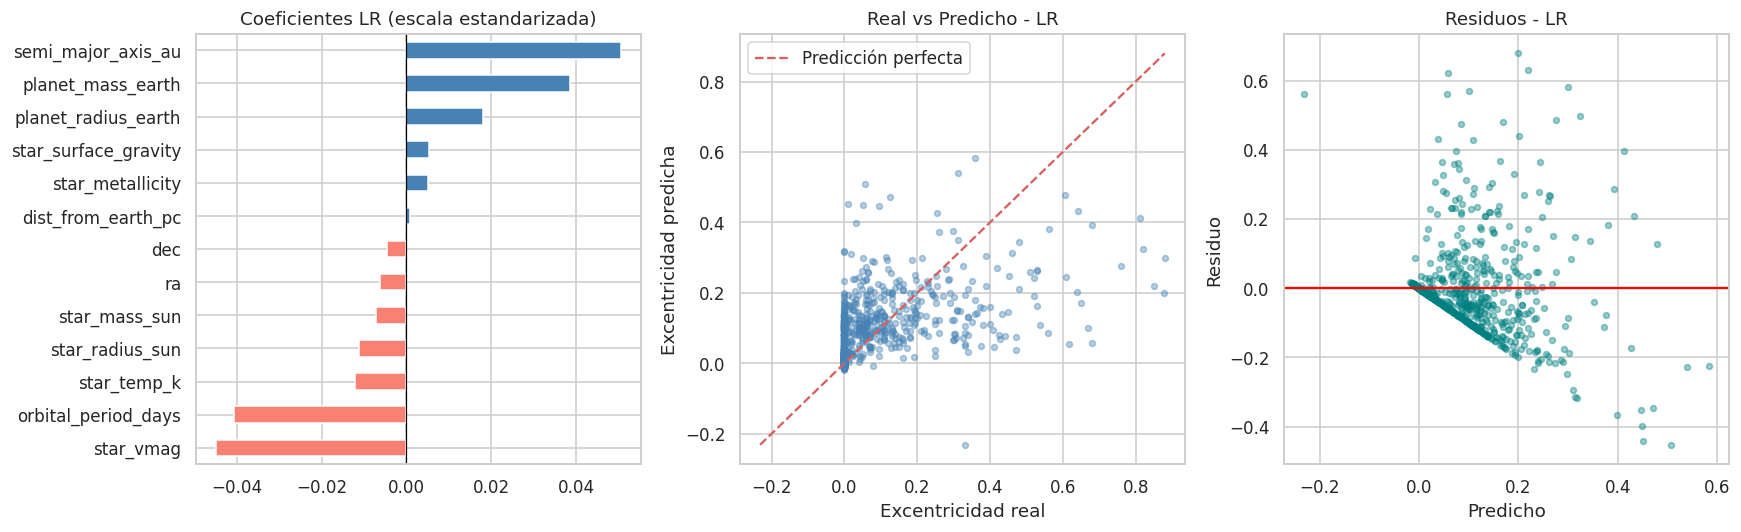

In [8]:
# ── 8. Diagnóstico visual — Regresión Lineal ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

coef = pd.Series(lr.coef_, index=FEATURES).sort_values()
colors = ["salmon" if c < 0 else "steelblue" for c in coef]
coef.plot(kind="barh", ax=axes[0], color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Coeficientes LR (escala estandarizada)")

axes[1].scatter(y_test, y_pred_lr, alpha=0.4, s=15, color="steelblue")
lim = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
axes[1].plot(lim, lim, "r--", linewidth=1.5, label="Predicción perfecta")
axes[1].set_xlabel("Excentricidad real")
axes[1].set_ylabel("Excentricidad predicha")
axes[1].set_title("Real vs Predicho - LR")
axes[1].legend()

residuals = y_test - y_pred_lr
axes[2].scatter(y_pred_lr, residuals, alpha=0.4, s=15, color="teal")
axes[2].axhline(0, color="red", linewidth=1.5)
axes[2].set_xlabel("Predicho")
axes[2].set_ylabel("Residuo")
axes[2].set_title("Residuos - LR")

plt.tight_layout()
plt.show()

## 4. Random Forest

Random Forest construye **100 árboles de decisión** sobre subconjuntos de datos y características (bootstrap), promediando sus predicciones.

**Ventaja clave:** Captura relaciones no lineales e interacciones complejas entre las propiedades astronómicas sin asumir una forma funcional previa.

In [9]:
# ── 9. Random Forest — Entrenamiento y métricas ─────────────────────────────
rf = RandomForestRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
cv_rf   = cross_val_score(rf, X, y, cv=5, scoring="r2")

print("=== Random Forest (n_estimators=100) ===")
print(f"R²        (test):  {r2_rf:.4f}")
print(f"RMSE      (test):  {rmse_rf:.4f}")
print(f"MAE       (test):  {mae_rf:.4f}")
print(f"R² CV-5fold:       {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}")

=== Random Forest (n_estimators=100) ===
R²        (test):  0.3850
RMSE      (test):  0.1065
MAE       (test):  0.0578
R² CV-5fold:       0.4180 +/- 0.0291


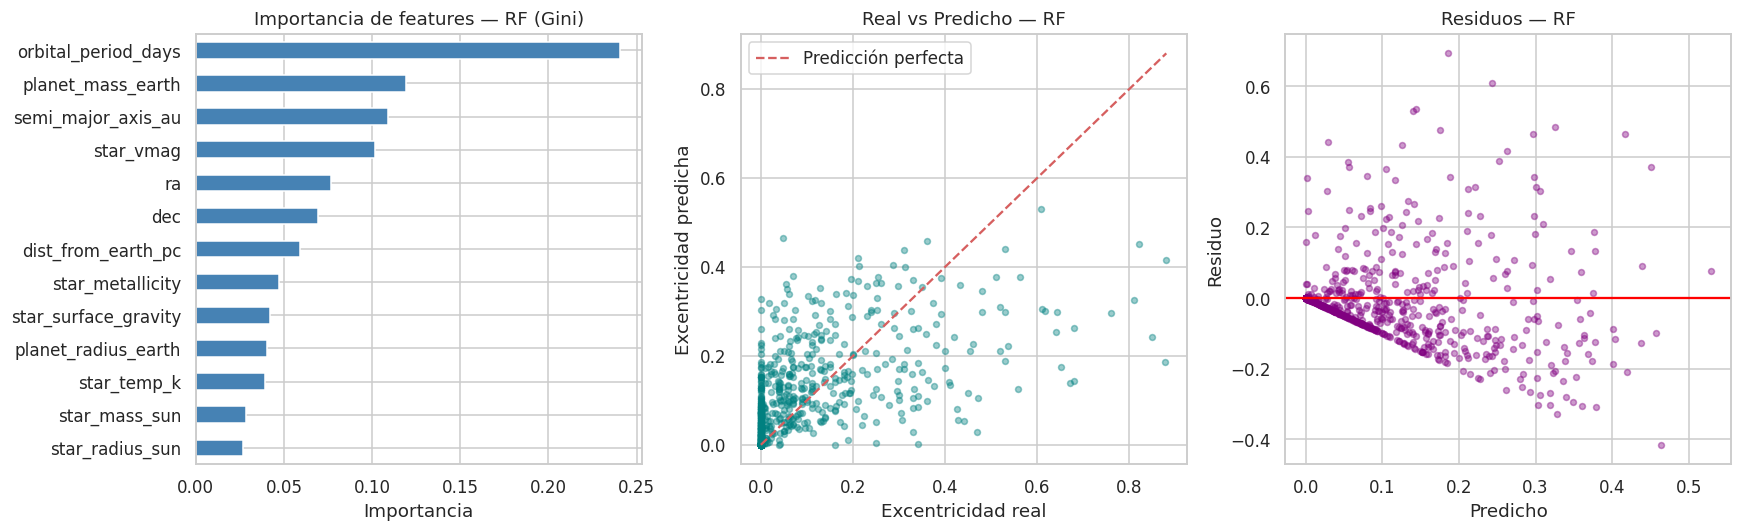

In [10]:
# ── 10. Diagnóstico visual — Random Forest ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Importancia de features — RF (Gini)")
axes[0].set_xlabel("Importancia")

axes[1].scatter(y_test, y_pred_rf, alpha=0.4, s=15, color="teal")
lim = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
axes[1].plot(lim, lim, "r--", linewidth=1.5, label="Predicción perfecta")
axes[1].set_xlabel("Excentricidad real")
axes[1].set_ylabel("Excentricidad predicha")
axes[1].set_title("Real vs Predicho — RF")
axes[1].legend()

residuals_rf = y_test - y_pred_rf
axes[2].scatter(y_pred_rf, residuals_rf, alpha=0.4, s=15, color="purple")
axes[2].axhline(0, color="red", linewidth=1.5)
axes[2].set_xlabel("Predicho")
axes[2].set_ylabel("Residuo")
axes[2].set_title("Residuos — RF")

plt.tight_layout()
plt.show()

## 5. Comparación de Modelos

                  R2 Test  RMSE Test  MAE Test      R2 CV-5fold
Modelo                                                         
Regresión Lineal   0.2721     0.1158    0.0681  0.3166+/-0.0415
Random Forest      0.3850     0.1065    0.0578  0.4180+/-0.0291



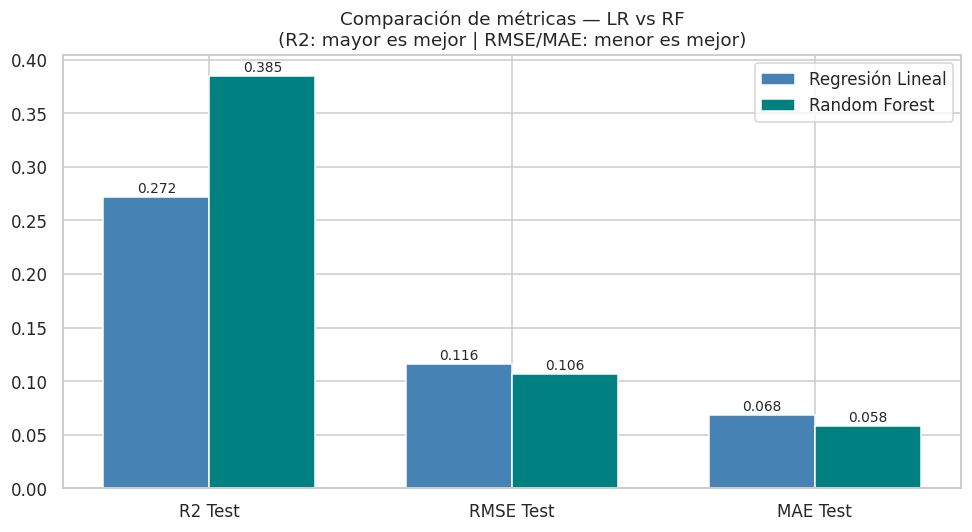

In [11]:
# ── 11. Tabla comparativa ───────────────────────────────────────────────────
results = pd.DataFrame({
    "Modelo":       ["Regresión Lineal", "Random Forest"],
    "R2 Test":      [round(r2_lr, 4),   round(r2_rf, 4)],
    "RMSE Test":    [round(rmse_lr, 4), round(rmse_rf, 4)],
    "MAE Test":     [round(mae_lr, 4),  round(mae_rf, 4)],
    "R2 CV-5fold":  [f"{cv_lr.mean():.4f}+/-{cv_lr.std():.4f}",
                     f"{cv_rf.mean():.4f}+/-{cv_rf.std():.4f}"],
})
print(results.set_index("Modelo").to_string())
print()

fig, ax = plt.subplots(figsize=(9, 5))
metrics  = ["R2 Test", "RMSE Test", "MAE Test"]
lr_vals  = [r2_lr, rmse_lr, mae_lr]
rf_vals  = [r2_rf, rmse_rf, mae_rf]
x = np.arange(len(metrics))
w = 0.35

b1 = ax.bar(x - w/2, lr_vals, w, label="Regresión Lineal", color="steelblue")
b2 = ax.bar(x + w/2, rf_vals, w, label="Random Forest",    color="teal")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_title("Comparación de métricas — LR vs RF\n(R2: mayor es mejor | RMSE/MAE: menor es mejor)", fontsize=12)
ax.legend()
for bar in list(b1) + list(b2):
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Conclusiones

1. **Desempeño:** Random Forest supera a la Regresión Lineal en todas las métricas ($R^2$, $RMSE$ y $MAE$).
2. **No linealidad:** La baja capacidad explicativa de la Regresión Lineal confirma que la excentricidad orbital depende de interacciones no lineales entre las propiedades del planeta y su estrella.
3. **Aplicación práctica:** El modelo entrenado con Random Forest permite estimar con mayor precisión la excentricidad faltante en el catálogo de exoplanetas de la NASA.

### Referencias
- NASA Exoplanet Archive: https://exoplanetarchive.ipac.caltech.edu/
- Dataset: https://www.kaggle.com/datasets/kanchana1990/nasa-exoplanet-archive-intelligence